# Data Access Utilities


:::{admonition} *Preliminary Data*!
:class: caution

This notebook includes multiple variables, scenarios, and GCMs at the daily timestep with global coverage, downscaled to the 0.25° resolution. The version currently released is a preliminary subset containing mean daily temperature (`tasmean`) for one historical scenario, one GCM, and two future scenarios (the G6-1.5 SAI scenario and SSP2-4.5). We welcome feedback on both the preliminary dataset and its access utilities to help guide continued development.
:::

This notebook demonstrates how to access, subset, and export SRM downscaling outputs for impact modeling. 

**Contents:**
1. Select datasets
2. Spatial Subsetting: Point lookup, bounding box, country/region mask
3. Temporal Subsetting
4. Variable Selection and Transforms 
5. Export to NetCDF/CSV/Parquet

## Workflow Overview

This notebook follows a **modular pipeline approach**. Each section builds on the previous one:

```
1. Select Datasets → 2. Spatial Subset → 3. Temporal Subset → 4. Transform Variables → 5. Export
```

**How to use this notebook:**

- **Cells marked with "CUSTOMIZE"**: These contain parameters you should modify for your specific use case (e.g., selecting variables, choosing a location)
- **Cells marked with "No modification needed"**: These apply the operations using your parameters - run them as-is
- **Helper function cells**: Reusable code you can use in your own workflows

**Chaining operations**: After each section, you'll have a dataset variable (e.g., `ds`, `ds_clipped`, `ds_subset`) that you can pass to the next section. You can skip sections you don't need or run them in different orders.

## 1. Prerequisites and Setup

Install dependencies if needed.
```bash
pip install xarray zarr dask icechunk geopandas xproj rasterix pooch flox
```

In [ ]:
import flox  # noqa - xarray groupby speedup
import geopandas as gpd
import icechunk
import numpy as np
import pandas as pd
import pooch
import xarray as xr
import xproj  # noqa - enables .proj accessor
from rasterix.rasterize import geometry_clip

## 2. Accessing the data



**What you'll accomplish in this section:**
- Load one of three SRM downscaling icechunk stores
- Choose between three scenarios: `historical`, `ssp245`, or `g6-1.5k`

**Available options:**
- **Scenarios**: `historical` (1978–2014), `ssp245` (2015–2100), `g6-1.5k` (2015–2100)
- **Model**: CESM2-WACCM
- **Variable**: `tas` (near-surface air temperature)

**Output**: A dataset (`ds`) used in sections 3–6.

### Data storage

The datasets shared here are stored on aws s3 and in the Icechunk format. [Icechunk](https://icechunk.io/en/stable/overview/) is an open-source format, that adds `git-like` transactions to Zarr. It's not too important that you understand it. We'll be using a helper function to load the data into Xarray.

In [ ]:
def load_downscaling_store(scenario: str) -> xr.Dataset:
    prefix_mapping = {
        "historical": "output/production/v0.6.0.post33_degrees/historical/CESM2-WACCM/tas/r3i1p1f1/global/5e6b6f6c/historical.icechunk",
        "g6-1.5k": "output/production/v0.6.0.post33_degrees/g6-1.5k/CESM2-WACCM/tas/003/global/5e6b6f6c/g6-1.5k.icechunk",
        "ssp245": "output/production/v0.6.0.post33_degrees/ssp245/CESM2-WACCM/tas/003/global/5e6b6f6c/ssp245.icechunk",
    }

    storage = icechunk.s3_storage(
        bucket="carbonplan-srm",
        prefix=prefix_mapping.get(scenario),
        anonymous=True,
        region="us-west-2",
    )
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")
    return xr.open_dataset(session.store, engine="zarr", chunks="auto")


historical_ds = load_downscaling_store(scenario="historical")
g6_ds = load_downscaling_store(scenario="g6-1.5k")
ssp245_ds = load_downscaling_store(scenario="ssp245")

### Selecting Your Datasets

Choose one of the datasets: `historical`, `ssp245` or `g6-1.5k`. For the following examples, we'll use historical, but feel free to switch.

In [4]:
ds = historical_ds

## 3. Spatial Subsetting

This section demonstrates three methods for spatial subsetting:
1. **Point lookup**: Extract a time series at a specific lat/lon location
2. **Bounding box**: Subset to a rectangular region
3. **Country/region mask**: Clip to a country or administrative boundary using shapefiles

Choose from three spatial subsetting methods (you can use just one or combine them):
- **Section 3.1 (Point Lookup)**: Extract time series for specific lat/lon coordinates
- **Section 3.2 (Bounding Box)**: Get data for a rectangular region defined by min/max lat/lon
- **Section 3.3 (Country/Region)**: Clip data to country or administrative boundaries

Skip this section entirely if you want the full global extent.

### 3.1 Point Lookup

**Use this method if**: You want time series data for specific locations (e.g., cities, weather stations, project sites).

Specify your target coordinates in the next cell.

In [5]:
# ===== CUSTOMIZE: Set your target location =====
target_lat = 37.7749  # Latitude of your point of interest
target_lon = -122.4194  # Longitude of your point of interest
# ===============================================

# No modification needed below - extracts the point data
ds_point_nearest = ds.sel(lat=target_lat, lon=target_lon, method="nearest")
print(f"Point subset shape: {dict(ds_point_nearest.sizes)}")
ds_point_nearest

Point subset shape: {'time': 13505}


<xarray.Dataset> Size: 270kB
Dimensions:    (time: 13505)
Coordinates:
  * time       (time) object 108kB 1978-01-01 00:00:00 ... 2014-12-31 00:00:00
    dayofyear  (time) int64 108kB dask.array<chunksize=(13505,), meta=np.ndarray>
    lon        float32 4B -122.5
    lat        float32 4B 37.75
Data variables:
    tas        (time) float32 54kB dask.array<chunksize=(13505,), meta=np.ndarray>
Attributes: (12/14)
    author:                      CarbonPlan
    processing:                  BCSD (quantile mapping bias correction + spa...
    bias_correction_method:      nonparametric_hybrid
    downscaling_method:          additive
    train_period:                1978-2014
    observation_dataset:         ERA5
    ...                          ...
    model:                       CESM2-WACCM
    scenario:                    G6-1.5K
    variable:                    tas
    ensemble_member:             003
    historical_ensemble_member:  r3i1p1f1
    ssp245_ensemble_member:      003

In [6]:
# ===== OPTIONAL: Extract multiple points at once =====
locations = {
    "San Francisco": (37.7749, -122.4194),
    "Los Angeles": (34.0522, -118.2437),
    "Seattle": (47.6062, -122.3321),
}

lats = xr.DataArray([lat for lat, lon in locations.values()], dims="location")
lons = xr.DataArray([lon for lat, lon in locations.values()], dims="location")
names = xr.DataArray(list(locations.keys()), dims="location")

multi_point = ds.sel(lat=lats, lon=lons, method="nearest").assign_coords(location=names)
print(multi_point)

<xarray.Dataset> Size: 378kB
Dimensions:    (time: 13505, location: 3)
Coordinates:
  * time       (time) object 108kB 1978-01-01 00:00:00 ... 2014-12-31 00:00:00
    dayofyear  (time) int64 108kB dask.array<chunksize=(13505,), meta=np.ndarray>
  * location   (location) <U13 156B 'San Francisco' 'Los Angeles' 'Seattle'
    lon        (location) float32 12B -122.5 -118.2 -122.2
    lat        (location) float32 12B 37.75 34.0 47.5
Data variables:
    tas        (time, location) float32 162kB dask.array<chunksize=(13505, 3), meta=np.ndarray>
Attributes: (12/14)
    author:                      CarbonPlan
    processing:                  BCSD (quantile mapping bias correction + spa...
    bias_correction_method:      nonparametric_hybrid
    downscaling_method:          additive
    train_period:                1978-2014
    observation_dataset:         ERA5
    ...                          ...
    model:                       CESM2-WACCM
    scenario:                    G6-1.5K
    varia

### 3.2 Bounding Box Subset

**Use this method if**: You want data for a rectangular region (e.g., a state, watershed, or study area).

Specify your bounding box coordinates in the next cell.

In [7]:
# ===== CUSTOMIZE: Set your bounding box =====
bbox = {
    "lon_min": -124.5,
    "lon_max": -114.0,
    "lat_min": 32.5,
    "lat_max": 42.0,
}
# ============================================

# No modification needed below
ds_bbox = ds.sel(
    lat=slice(bbox["lat_min"], bbox["lat_max"]), lon=slice(bbox["lon_min"], bbox["lon_max"])
)

# Persist triggers compute now so downstream cells are fast
ds_bbox = ds_bbox.persist()

print(f"Original shape: lat={ds.sizes.get('lat', 'N/A')}, lon={ds.sizes.get('lon', 'N/A')}")
print(f"Subset shape: lat={ds_bbox.sizes.get('lat', 'N/A')}, lon={ds_bbox.sizes.get('lon', 'N/A')}")
ds_bbox

Original shape: lat=721, lon=1440
Subset shape: lat=39, lon=43


<xarray.Dataset> Size: 91MB
Dimensions:    (time: 13505, lat: 39, lon: 43)
Coordinates:
  * time       (time) object 108kB 1978-01-01 00:00:00 ... 2014-12-31 00:00:00
    dayofyear  (time) int64 108kB dask.array<chunksize=(13505,), meta=np.ndarray>
  * lat        (lat) float32 156B 32.5 32.75 33.0 33.25 ... 41.5 41.75 42.0
  * lon        (lon) float32 172B -124.5 -124.2 -124.0 ... -114.5 -114.2 -114.0
Data variables:
    tas        (time, lat, lon) float32 91MB dask.array<chunksize=(13505, 22, 34), meta=np.ndarray>
Attributes: (12/14)
    author:                      CarbonPlan
    processing:                  BCSD (quantile mapping bias correction + spa...
    bias_correction_method:      nonparametric_hybrid
    downscaling_method:          additive
    train_period:                1978-2014
    observation_dataset:         ERA5
    ...                          ...
    model:                       CESM2-WACCM
    scenario:                    G6-1.5K
    variable:                    tas
    ensemble_member:             003
    historical_ensemble_member:  r3i1p1f1
    ssp245_ensemble_member:      003

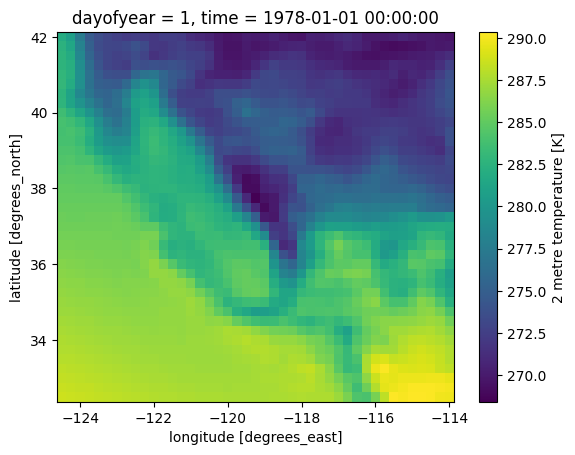

In [8]:
# ===== No modification needed - visualizes your subset =====
ds_bbox.tas.isel(time=0).squeeze().plot();

Western US subset: {'time': 13505, 'lat': 73, 'lon': 93}


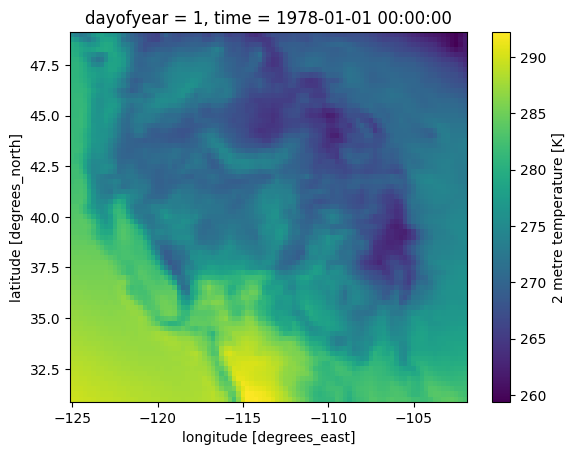

In [9]:
# ===== Helper function - can be reused in your workflows =====
def subset_bbox(ds, lon_min, lon_max, lat_min, lat_max):
    # Handle both ascending and descending latitude coordinates
    lat_slice = slice(lat_min, lat_max) if ds.lat[0] < ds.lat[-1] else slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max) if ds.lon[0] < ds.lon[-1] else slice(lon_max, lon_min)
    return ds.sel(lat=lat_slice, lon=lon_slice)


# Example usage
ds_western_us = subset_bbox(ds, lon_min=-125, lon_max=-102, lat_min=31, lat_max=49)
print(f"Western US subset: {dict(ds_western_us.sizes)}")
ds_western_us.tas.squeeze().isel(time=0).plot()

### 3.3 Country/Region Mask

**Use this method if**: You want data clipped to country borders or administrative boundaries.

Specify your country/region name or provide a custom boundary file.

In [10]:
# ===== CUSTOMIZE: Choose your boundary source =====
# Option A: local GIS / vector geometry file (recommended if you have one)
# Geopandas supports many vector format: geoparquet, shapefile, geopackage etc.
# from pathlib import Path
# boundaries_gpq = Path("path/to/your/boundaries.gpq")
# countries = gpd.read_parquet(boundaries_gpq)
# or
# countries = gpd.read_file(boundaries_shapefile)


# Option B: download Natural Earth (no local file needed)

countries_url = "https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip"
countries_path = pooch.retrieve(countries_url, known_hash=None, processor=pooch.Unzip())
countries = gpd.read_file([p for p in countries_path if p.endswith(".shp")][0])
# ==================================================

print(f"Available regions: {countries.shape[0]}")
countries[["NAME", "CONTINENT"]].head(10)

Available regions: 242


,NAME,CONTINENT
0,Zimbabwe,Africa
1,Zambia,Africa
2,Yemen,Asia
3,Vietnam,Asia
4,Venezuela,South America
5,Vatican,Europe
6,Vanuatu,Oceania
7,Uzbekistan,Asia
8,Uruguay,South America
9,Micronesia,Oceania


In [11]:
# ===== No modification needed - assigns CRS to dataset =====
ds_with_crs = ds.proj.assign_crs(spatial_ref="epsg:4326")
ds_with_crs

<xarray.Dataset> Size: 56GB
Dimensions:      (time: 13505, lat: 721, lon: 1440)
Coordinates:
  * time         (time) object 108kB 1978-01-01 00:00:00 ... 2014-12-31 00:00:00
    dayofyear    (time) int64 108kB dask.array<chunksize=(13505,), meta=np.ndarray>
  * lat          (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float32 6kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * spatial_ref  int64 8B 0
Data variables:
    tas          (time, lat, lon) float32 56GB dask.array<chunksize=(13505, 32, 64), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)
Attributes: (12/14)
    author:                      CarbonPlan
    processing:                  BCSD (quantile mapping bias correction + spa...
    bias_correction_method:      nonparametric_hybrid
    downscaling_method:          additive
    train_period:                1978-2014
    observation_dataset:         ERA5
    ...                          ...
    model:                       CESM2-WACCM
    scenario:                    G6-1.5K
    variable:                    tas
    ensemble_member:             003
    historical_ensemble_member:  r3i1p1f1
    ssp245_ensemble_member:      003

Selected country: India
Bounds: [68.16503906  6.74868164 97.34355469 35.49589844]


<Axes: >

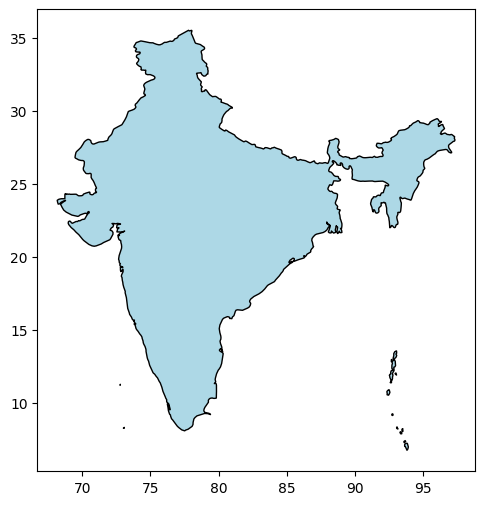

In [12]:
# ===== CUSTOMIZE: Select your country/region =====
country_name = "India"  # Change this to your country of interest
# ================================================

# No modification needed below - selects the country
country = countries[countries["NAME"] == country_name]
print(f"Selected country: {country_name}")
print(f"Bounds: {country.total_bounds}")  # [minx, miny, maxx, maxy]
country.plot(figsize=(8, 6), edgecolor="black", facecolor="lightblue")

#### Geometry Clip 

Clips to geometry bounds and masks values outside. Use this method for most workflows.

In [13]:
# ===== No modification needed - clips to country geometry =====


bounds = country.total_bounds
ds_bbox_country = ds.sel(lat=slice(bounds[1], bounds[3]), lon=slice(bounds[0], bounds[2])).sortby(
    "lat", ascending=False
)

ds_clipped = (
    geometry_clip(ds_bbox_country, country[["geometry"]], xdim="lon", ydim="lat", all_touched=True)
    .sortby("lat")
    .drop_vars("spatial_ref", errors="ignore")
)

ds_clipped = ds_clipped.persist()

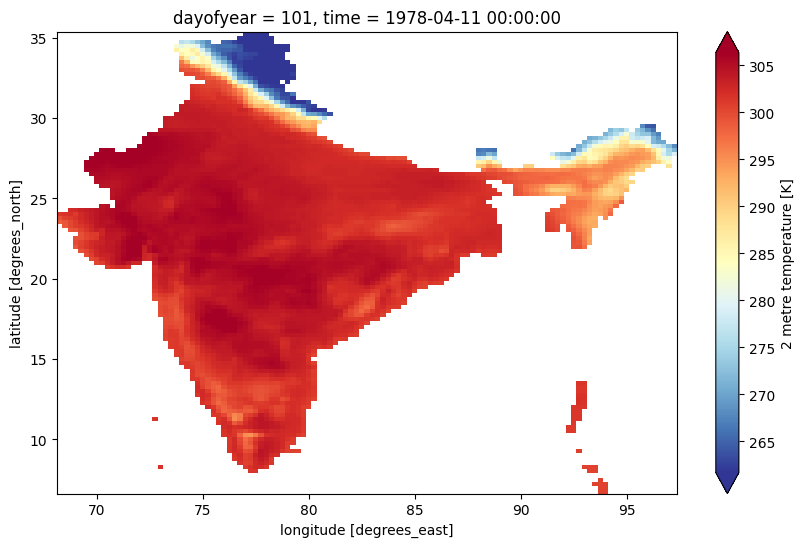

In [14]:
# ===== No modification needed - visualizes clipped data =====
ds_clipped["tas"].isel(time=100).squeeze().drop_vars("spatial_ref", errors="ignore").plot(
    figsize=(10, 6), robust=True, cmap="RdYlBu_r"
)

### 3.4 Spatial Subsetting Summary

| Method | Use Case | Performance | Package | Covered in |
|--------|----------|-------------|---------|------------|
| **Point (nearest)** | Single location time series | Fast | xarray | Section 3.1 |
| **Bounding box** | Rectangular regions | Fast | xarray | Section 3.2 |
| **geometry_mask** | Create boolean mask for geometries | Fast, Dask-aware | rasterix | Section 3.3 |
| **geometry_clip** | Clip to geometry bounds + mask | Fast, Dask-aware | rasterix | Section 3.3 |

**Tips:**
- Always assign CRS to your dataset before using rasterix: `ds.proj.assign_crs(spatial_ref="epsg:4326")`
- Use chunked datasets for large files that don't fit in memory
- `geometry_clip` is recommended for most use cases as it reduces data volume

## 4. Temporal Subsetting

Choose your method:
- **Section 4.1 (Date Range)**: Select specific years or date ranges
- **Section 4.2 (Months/Seasons)**: Filter to specific months or meteorological seasons
- **Section 4.3 (Resampling)**: Change time frequency (e.g., daily to annual)

You can apply temporal subsetting to any dataset from Section 3, or to `ds` directly if you skipped spatial subsetting.

In [15]:
# ===== No modification needed - checks time range =====
# This works with whatever dataset you created in Section 3 (ds_clipped, ds_bbox, ds_point, or ds)
print(f"Time range: {ds_clipped.time.values[0]} to {ds_clipped.time.values[-1]}")
print(f"Total time steps: {ds_clipped.sizes['time']}")

Time range: 1978-01-01 00:00:00 to 2014-12-31 00:00:00
Total time steps: 13505


### 4.1 Date Range Selection

**Use this method if**: You need data for a specific time period (e.g., historical baseline, specific decade).

Specify your date range in the next cells.

In [16]:
# ===== CUSTOMIZE: Set your date range =====
start_date = "1990-01-01"
end_date = "1999-12-31"
# ==========================================

# No modification needed below
ds_1990s = ds_clipped.sel(time=slice(start_date, end_date))
print(f"1990s subset: {ds_1990s.sizes['time']} time steps")
print(f"Date range: {ds_1990s.time.values[0]} to {ds_1990s.time.values[-1]}")
ds_1990s

1990s subset: 3650 time steps
Date range: 1990-01-01 00:00:00 to 1999-12-31 00:00:00


<xarray.Dataset> Size: 197MB
Dimensions:    (time: 3650, lat: 115, lon: 117)
Coordinates:
  * time       (time) object 29kB 1990-01-01 00:00:00 ... 1999-12-31 00:00:00
    dayofyear  (time) int64 29kB dask.array<chunksize=(3650,), meta=np.ndarray>
  * lat        (lat) float32 460B 6.75 7.0 7.25 7.5 ... 34.5 34.75 35.0 35.25
  * lon        (lon) float32 468B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
Data variables:
    tas        (time, lat, lon) float32 196MB dask.array<chunksize=(3650, 28, 31), meta=np.ndarray>
Attributes: (12/14)
    author:                      CarbonPlan
    processing:                  BCSD (quantile mapping bias correction + spa...
    bias_correction_method:      nonparametric_hybrid
    downscaling_method:          additive
    train_period:                1978-2014
    observation_dataset:         ERA5
    ...                          ...
    model:                       CESM2-WACCM
    scenario:                    G6-1.5K
    variable:                    tas
    ensemble_member:             003
    historical_ensemble_member:  r3i1p1f1
    ssp245_ensemble_member:      003

In [17]:
# ===== CUSTOMIZE: Select a single year =====
target_year = "1995"
# ===========================================

# No modification needed below
ds_1995 = ds_clipped.sel(time=target_year)
print(f"Year {target_year}: {ds_1995.sizes['time']} time steps")
ds_1995

Year 1995: 365 time steps


<xarray.Dataset> Size: 20MB
Dimensions:    (time: 365, lat: 115, lon: 117)
Coordinates:
  * time       (time) object 3kB 1995-01-01 00:00:00 ... 1995-12-31 00:00:00
    dayofyear  (time) int64 3kB dask.array<chunksize=(365,), meta=np.ndarray>
  * lat        (lat) float32 460B 6.75 7.0 7.25 7.5 ... 34.5 34.75 35.0 35.25
  * lon        (lon) float32 468B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
Data variables:
    tas        (time, lat, lon) float32 20MB dask.array<chunksize=(365, 28, 31), meta=np.ndarray>
Attributes: (12/14)
    author:                      CarbonPlan
    processing:                  BCSD (quantile mapping bias correction + spa...
    bias_correction_method:      nonparametric_hybrid
    downscaling_method:          additive
    train_period:                1978-2014
    observation_dataset:         ERA5
    ...                          ...
    model:                       CESM2-WACCM
    scenario:                    G6-1.5K
    variable:                    tas
    ensemble_member:             003
    historical_ensemble_member:  r3i1p1f1
    ssp245_ensemble_member:      003

### 4.2 Month and Season Selection

**Use this method if**: You need data for specific months or meteorological seasons (e.g., summer heat analysis, monsoon season).

Specify months or seasons in the next cells.

In [18]:
# ===== CUSTOMIZE: Select specific months =====
# Months: 1=Jan, 2=Feb, ..., 12=Dec
target_months = [6, 7, 8]  # Summer months (JJA)
# =============================================

# No modification needed below
ds_summer = ds_clipped.sel(time=ds_clipped.time.dt.month.isin(target_months))
print(f"Selected months: {ds_summer.sizes['time']} time steps")

Selected months: 3404 time steps


In [19]:
# ===== CUSTOMIZE: Select by season =====
# Options: "DJF" (winter), "MAM" (spring), "JJA" (summer), "SON" (fall)
target_season = "DJF"
# =======================================

# No modification needed below
ds_winter = ds_clipped.sel(time=ds_clipped.time.dt.season == target_season)
print(f"{target_season} season: {ds_winter.sizes['time']} time steps")

DJF season: 3330 time steps


In [20]:
# ===== No modification needed - calculates seasonal climatology =====
ds_seasonal_clim = ds_clipped.groupby("time.season").mean("time")
print(f"Seasonal climatology dimensions: {dict(ds_seasonal_clim.sizes)}")
ds_seasonal_clim

Seasonal climatology dimensions: {'season': 4, 'lat': 115, 'lon': 117}


<xarray.Dataset> Size: 216kB
Dimensions:  (season: 4, lat: 115, lon: 117)
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat      (lat) float32 460B 6.75 7.0 7.25 7.5 7.75 ... 34.5 34.75 35.0 35.25
  * lon      (lon) float32 468B 68.25 68.5 68.75 69.0 ... 96.5 96.75 97.0 97.25
Data variables:
    tas      (season, lat, lon) float32 215kB dask.array<chunksize=(4, 28, 31), meta=np.ndarray>
Attributes: (12/14)
    author:                      CarbonPlan
    processing:                  BCSD (quantile mapping bias correction + spa...
    bias_correction_method:      nonparametric_hybrid
    downscaling_method:          additive
    train_period:                1978-2014
    observation_dataset:         ERA5
    ...                          ...
    model:                       CESM2-WACCM
    scenario:                    G6-1.5K
    variable:                    tas
    ensemble_member:             003
    historical_ensemble_member:  r3i1p1f1
    ssp245_ensemble_member:      003

### 4.3 Temporal Resampling

**Use this method if**: You need to change the time frequency of your data (e.g., monthly to annual averages for trend analysis).

In [21]:
# ===== No modification needed - resamples to annual means =====
ds_annual = ds_clipped.resample(time="YE").mean()
print(f"Annual resampled: {ds_annual.sizes['time']} time steps")

Annual resampled: 37 time steps


In [22]:
# ===== Helper function - flexible temporal subsetting =====
def subset_time(ds, start_date=None, end_date=None, months=None, seasons=None):
    """
    Flexible temporal subsetting of a dataset.

    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset with time coordinate
    start_date : str, optional
        Start date in 'YYYY-MM-DD' format
    end_date : str, optional
        End date in 'YYYY-MM-DD' format
    months : list of int, optional
        List of months to select (1-12)
    seasons : list of str, optional
        List of seasons to select ('DJF', 'MAM', 'JJA', 'SON')

    Returns
    -------
    xarray.Dataset
        Temporally subsetted dataset
    """
    result = ds

    # Date range selection
    if start_date or end_date:
        result = result.sel(time=slice(start_date, end_date))

    # Month selection
    if months:
        result = result.sel(time=result.time.dt.month.isin(months))

    # Season selection
    if seasons:
        result = result.sel(time=result.time.dt.season.isin(seasons))

    return result


# Example usage - summer months for 1990-2000 (no modification needed)
ds_summer_90s = subset_time(
    ds_clipped, start_date="1990-01-01", end_date="1999-12-31", months=[6, 7, 8]
)
print(f"Summer 1990s: {ds_summer_90s.sizes['time']} time steps")

Summer 1990s: 920 time steps


### 4.4 Temporal Subsetting Summary

| Method | Use Case | Example |
|--------|----------|---------|
| **Date range** | Specific time period | `ds.sel(time=slice("1990", "2000"))` |
| **Single year** | One year of data | `ds.sel(time="1995")` |
| **Month filter** | Specific months | `ds.sel(time=ds.time.dt.month.isin([6,7,8]))` |
| **Season filter** | Meteorological seasons | `ds.sel(time=ds.time.dt.season=="DJF")` |
| **Resample** | Change time frequency | `ds.resample(time="YE").mean()` |
| **Groupby** | Climatologies | `ds.groupby("time.season").mean()` |

## 5. Variable Selection and Transforms

Choose your operations:
- **Section 5.1**: Select which variables to keep
- **Section 5.2**: Apply unit conversions (Kelvin to Celsius)
- **Section 5.3**: Compute derived variables or anomalies

Skip to Section 6 if your dataset already has the variables and units you need.

### 5.1 Variable Selection

Select specific variables from a multi-variable dataset.

In [23]:
# ===== No modification needed - view available variables =====
print("Available variables:")
for var in ds_clipped.data_vars:
    print(f"  - {var}: {ds_clipped[var].attrs.get('long_name', 'No description')}")

Available variables:
  - tas: 2 metre temperature


In [24]:
# ===== CUSTOMIZE: Select specific variables =====
variables_to_keep = ["tas"]
# ================================================

# No modification needed below
ds_temp_vars = ds_clipped[variables_to_keep]
print(f"Selected variables: {list(ds_temp_vars.data_vars)}")

Selected variables: ['tas']


### 5.2 Unit Conversions

Common unit conversions for climate data.

In [25]:
# ===== No modification needed - check current units =====
print(f"tas units: {ds_clipped['tas'].attrs.get('units', 'unknown')}")

tas units: K


In [26]:
# ===== Helper function - temperature conversion =====
def kelvin_to_celsius(da):
    da_celsius = da - 273.15
    da_celsius.attrs = da.attrs.copy()
    da_celsius.attrs["units"] = "°C"
    return da_celsius


# No modification needed - applies conversion
tas_celsius = kelvin_to_celsius(ds_clipped["tas"])
print(f"Original mean: {float(ds_clipped['tas'].mean()):.2f} K")
print(f"Converted mean: {float(tas_celsius.mean()):.2f} °C")

Original mean: 296.47 K
Converted mean: 23.32 °C


### 5.3 Computing Derived Variables

Calculate new variables from existing ones.

In [27]:
# ===== No modification needed - creates dataset with converted units =====
ds_converted = ds_clipped.copy()
ds_converted["tas_celsius"] = kelvin_to_celsius(ds_converted["tas"])

print("Dataset with converted variables:")
print(f"Variables: {list(ds_converted.data_vars)}")
ds_converted

Dataset with converted variables:
Variables: ['tas', 'tas_celsius']


<xarray.Dataset> Size: 1GB
Dimensions:      (time: 13505, lat: 115, lon: 117)
Coordinates:
  * time         (time) object 108kB 1978-01-01 00:00:00 ... 2014-12-31 00:00:00
    dayofyear    (time) int64 108kB dask.array<chunksize=(13505,), meta=np.ndarray>
  * lat          (lat) float32 460B 6.75 7.0 7.25 7.5 ... 34.5 34.75 35.0 35.25
  * lon          (lon) float32 468B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
Data variables:
    tas          (time, lat, lon) float32 727MB dask.array<chunksize=(13505, 28, 31), meta=np.ndarray>
    tas_celsius  (time, lat, lon) float32 727MB dask.array<chunksize=(13505, 28, 31), meta=np.ndarray>
Attributes: (12/14)
    author:                      CarbonPlan
    processing:                  BCSD (quantile mapping bias correction + spa...
    bias_correction_method:      nonparametric_hybrid
    downscaling_method:          additive
    train_period:                1978-2014
    observation_dataset:         ERA5
    ...                          ...
    model:                       CESM2-WACCM
    scenario:                    G6-1.5K
    variable:                    tas
    ensemble_member:             003
    historical_ensemble_member:  r3i1p1f1
    ssp245_ensemble_member:      003

In [28]:
# ===== CUSTOMIZE: Set baseline period for anomalies =====
baseline_start = "1980-01-01"
baseline_end = "2000-12-31"
# ========================================================

# No modification needed below - calculates anomalies
baseline = ds_clipped.sel(time=slice(baseline_start, baseline_end))
baseline_clim = baseline.groupby("time.month").mean("time")

# Calculate anomalies
anomalies = ds_clipped.groupby("time.month") - baseline_clim
print(f"Anomalies computed relative to {baseline_start} to {baseline_end}")
anomalies

Anomalies computed relative to 1980-01-01 to 2000-12-31


<xarray.Dataset> Size: 727MB
Dimensions:    (time: 13505, lon: 117, lat: 115)
Coordinates:
  * time       (time) object 108kB 1978-01-01 00:00:00 ... 2014-12-31 00:00:00
    dayofyear  (time) int64 108kB dask.array<chunksize=(13505,), meta=np.ndarray>
    month      (time) int64 108kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12
  * lon        (lon) float32 468B 68.25 68.5 68.75 69.0 ... 96.75 97.0 97.25
  * lat        (lat) float32 460B 6.75 7.0 7.25 7.5 ... 34.5 34.75 35.0 35.25
Data variables:
    tas        (time, lat, lon) float32 727MB dask.array<chunksize=(12, 28, 31), meta=np.ndarray>
Attributes: (12/14)
    author:                      CarbonPlan
    processing:                  BCSD (quantile mapping bias correction + spa...
    bias_correction_method:      nonparametric_hybrid
    downscaling_method:          additive
    train_period:                1978-2014
    observation_dataset:         ERA5
    ...                          ...
    model:                       CESM2-WACCM
    scenario:                    G6-1.5K
    variable:                    tas
    ensemble_member:             003
    historical_ensemble_member:  r3i1p1f1
    ssp245_ensemble_member:      003

### 5.4 Applying Custom Transformations

Apply custom functions across the dataset using xarray's `apply_ufunc` or simple arithmetic.

In [29]:
# ===== CUSTOMIZE: Set rolling window size =====
window_days = 30
# ==============================================

# No modification needed below
tas_rolling = ds_clipped["tas"].rolling(time=window_days, center=True).mean()
print(f"Rolling mean shape: {dict(tas_rolling.sizes)}")

# Calculate percentiles
tas_p95 = ds_clipped["tas"].quantile(0.95, dim="time")
print(f"95th percentile shape: {dict(tas_p95.sizes)}")

Rolling mean shape: {'time': 13505, 'lat': 115, 'lon': 117}
95th percentile shape: {'lat': 115, 'lon': 117}


In [30]:
# ===== Helper function - standardize data =====
def standardize(da, dim="time"):
    """Standardize data to z-scores along a dimension."""
    mean = da.mean(dim=dim)
    std = da.std(dim=dim)
    return (da - mean) / std


# No modification needed - applies standardization
tas_zscore = standardize(ds_clipped["tas"])
print(f"Z-score mean: {float(tas_zscore.mean()):.6f} (should be ~0)")
print(f"Z-score std: {float(tas_zscore.std()):.6f} (should be ~1)")

/Users/nrhagen/Documents/carbonplan/SRM/.venv/lib/python3.13/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Z-score mean: -0.000002 (should be ~0)


/Users/nrhagen/Documents/carbonplan/SRM/.venv/lib/python3.13/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Z-score std: 1.000000 (should be ~1)


## 6. Export to Zarr/NetCDF/CSV/Parquet

Choose your export format:
- **Section 6.1 (NetCDF)**: Preserves all metadata, standard for climate science
- **Section 6.2 (CSV)**: Simple tabular exports, works with Excel and other tools
- **Section 6.3 (Parquet)**: Large tabular datasets, efficient compression
- **Section 6.4 (Zarr)**: Best performance — preserves chunking, lazy re-open, fastest writes

**Note**: Subset spatially and temporally before exporting — full global data is ~130 GB per scenario.

In [31]:
# ===== CUSTOMIZE: Set your output directory =====
from pathlib import Path

# Change this path to your desired location (relative or absolute path)
# Current setting saves files in an 'exports' folder in the current directory
output_dir = Path("./exports")
# ================================================

# No modification needed below
output_dir.mkdir(exist_ok=True)
print(f"Output directory: {output_dir.absolute()}")

Output directory: /Users/nrhagen/Documents/carbonplan/SRM/docs/data-access-notebooks/exports


### 6.1 Export to NetCDF

NetCDF is a standard format for gridded climate data. It preserves coordinates, attributes, and metadata.

In [ ]:
# ===== CUSTOMIZE: Set export time range =====
export_start = "1990-01-01"
export_end = "1995-12-31"
# ===========================================

# No modification needed below - prepares subset for export
ds_export = ds_clipped.sel(time=slice(export_start, export_end))
print(f"Export dataset shape: {dict(ds_export.sizes)}")

# ===== CUSTOMIZE: Set output filename =====
netcdf_filename = "india_climate_1990-1995.nc"
# ==========================================

netcdf_path = output_dir / netcdf_filename
ds_export.to_netcdf(netcdf_path)
print(f"Compressed file size: {netcdf_path.stat().st_size / 1024**2:.1f} MB")

### 6.2 Export to CSV

CSV format is useful for point data or when sharing with non-Python tools. Best suited for 1D or 2D data. 

In [33]:
# ===== CUSTOMIZE: Set point location for CSV export =====
point_lat = 28.6  # Delhi, India
point_lon = 77.2
# ========================================================

# No modification needed below - extracts point and converts to DataFrame
point_data = ds_export.sel(lat=point_lat, lon=point_lon, method="nearest")
df_point = point_data.to_dataframe().reset_index()
print(f"Point data shape: {df_point.shape}")
df_point.head()

Point data shape: (2190, 5)


,time,tas,dayofyear,lon,lat
0,1990-01-01 00:00:00,282.410736,1,77.25,28.5
1,1990-01-02 00:00:00,284.907501,2,77.25,28.5
2,1990-01-03 00:00:00,285.011292,3,77.25,28.5
3,1990-01-04 00:00:00,284.317108,4,77.25,28.5
4,1990-01-05 00:00:00,283.801819,5,77.25,28.5


In [34]:
# ===== CUSTOMIZE: Set CSV filename =====
csv_filename = "delhi_climate_1990-1995.csv"
# =======================================

# No modification needed below
csv_path = output_dir / csv_filename
df_point.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")
print(f"File size: {csv_path.stat().st_size / 1024:.1f} KB")

Saved to: exports/delhi_climate_1990-1995.csv
File size: 94.9 KB


In [35]:
# ===== No modification needed - exports area-weighted regional mean =====
weights = np.cos(np.deg2rad(ds_export.lat))
ds_weighted_mean = ds_export.weighted(weights).mean(dim=["lat", "lon"])

df_regional = ds_weighted_mean.to_dataframe().reset_index()
csv_regional_path = output_dir / "india_regional_mean_1990-1995.csv"
df_regional.to_csv(csv_regional_path, index=False)
print(f"Regional mean saved to: {csv_regional_path}")
df_regional.head()

Regional mean saved to: exports/india_regional_mean_1990-1995.csv


,time,dayofyear,tas
0,1990-01-01 00:00:00,1,287.370178
1,1990-01-02 00:00:00,2,287.902771
2,1990-01-03 00:00:00,3,288.380737
3,1990-01-04 00:00:00,4,288.758636
4,1990-01-05 00:00:00,5,289.055298


### 6.3 Export to Parquet

Parquet is an efficient columnar format ideal for large tabular datasets. It's faster to read/write than CSV and supports compression.

In [36]:
# ===== No modification needed - flattens gridded data to DataFrame =====
# Note: Using just 1 year for demo to keep file size manageable
ds_small = ds_export.sel(time=slice("1990-01-01", "1990-12-31"))
df_grid = ds_small.to_dataframe().reset_index()
print(f"Flattened grid shape: {df_grid.shape}")

Flattened grid shape: (4911075, 5)


In [37]:
# ===== CUSTOMIZE: Set Parquet filename =====
parquet_filename = "india_climate_1990.parquet"
# ===========================================

# No modification needed below
parquet_path = output_dir / parquet_filename

df_grid["time"] = pd.to_datetime(df_grid["time"].astype(str))
df_grid.to_parquet(parquet_path, index=False)


print(f"Saved to: {parquet_path}")
print(f"File size: {parquet_path.stat().st_size / 1024**2:.1f} MB")

Saved to: exports/india_climate_1990.parquet
File size: 9.2 MB


### 6.4 Export to Zarr

Zarr preserves chunking and encoding from the source store and can be re-opened lazily with xarray. Better performance than NetCDF for gridded data — faster reads and writes.

**Note**: Zarr writes a directory, not a single file. 
Note: If you're on an HPC file system, standard zarr can cause [issues](https://www.unidata.ucar.edu/blogs/news/entry/netcdf-vs-zarr-an-incomplete) due to the large number of individual files/chunks. However, the Sharding spec in Zarr V3 should help alleviate that. This is all far beyond the scope of this notebook though. 

In [ ]:
# ===== CUSTOMIZE: Set Zarr store name =====
zarr_filename = "india_climate_1990-1995.zarr"
# ==========================================

# No modification needed below
zarr_path = output_dir / zarr_filename
ds_export.tas.chunk("auto").to_zarr(zarr_path, mode="w")
print(f"Saved to: {zarr_path}")

# Re-open lazily to verify
ds_from_zarr = xr.open_dataset(zarr_path, engine="zarr", chunks="auto")
print(f"Re-opened: {dict(ds_from_zarr.sizes)}")
ds_from_zarr

### 6.5 Export Format Summary

| Format | Best For | Pros | Cons |
|--------|----------|------|------|
| **NetCDF** | Gridded climate data, archiving | Preserves coordinates, metadata, CF-compliant | Slower I/O, loads full chunks |
| **CSV** | Point data, simple sharing | Universal compatibility | Large files, slow I/O, no compression |
| **Parquet** | Large tabular datasets | Fast I/O, compressed, columnar | Requires pyarrow/fastparquet |
| **Zarr** | Gridded subsets for further computation | Best performance — preserves chunking, lazy re-open, fast writes | Directory output, not a single file |

**Tips:**
- Use Zarr when the exported subset will feed into further xarray/dask workflows.
- Use NetCDF for archiving or if you are using tools that don't work with Zarr.
- Use CSV for small datasets or when sharing with Excel/non-Python users.
- Use Parquet for large tabular datasets or GIS tools.

## Complete Workflow Example

**This section demonstrates how to chain multiple operations together** for a complete analysis pipeline. You can adapt this pattern for your own workflow.

**Example scenario**: Extract summer (JJA) climate data for California from 2015-2020, convert units, and export to netCDF.

In [39]:
# ===== CUSTOMIZE ALL PARAMETERS FOR YOUR WORKFLOW =====

# 1. Scenario selection
workflow_scenario = "ssp245"  # "historical", "ssp245", or "g6-1.5k"

# 2. Spatial subsetting (bounding box for California)
workflow_bbox = {
    "lon_min": -124.5,
    "lon_max": -114.0,
    "lat_min": 32.5,
    "lat_max": 42.0,
}

# 3. Temporal subsetting
workflow_start_date = "2015-01-01"
workflow_end_date = "2020-12-31"
workflow_months = [6, 7, 8]  # Summer months (JJA)

# 4. Output
workflow_output_file = "california_summer_ssp245_2015-2020.nc"

# =======================================================

In [40]:
# ===== No modification needed - executes complete workflow =====

# Step 1: Load scenario
print("Step 1: Loading dataset...")
ds_workflow = load_downscaling_store(scenario=workflow_scenario)
print(f"  Loaded dataset with shape: {dict(ds_workflow.sizes)}")

# Step 2: Spatial subset (bounding box)
print("\nStep 2: Applying spatial subset...")
ds_workflow = ds_workflow.sel(
    lat=slice(workflow_bbox["lat_min"], workflow_bbox["lat_max"]),
    lon=slice(workflow_bbox["lon_min"], workflow_bbox["lon_max"]),
)
print(f"  Spatial subset: {dict(ds_workflow.sizes)}")

# Step 3: Temporal subset
print("\nStep 3: Applying temporal subset...")
ds_workflow = ds_workflow.sel(time=slice(workflow_start_date, workflow_end_date))
ds_workflow = ds_workflow.sel(time=ds_workflow.time.dt.month.isin(workflow_months))
print(f"  Temporal subset: {ds_workflow.sizes['time']} time steps")

# Step 4: Unit conversion
print("\nStep 4: Converting units...")
ds_workflow["tas_celsius"] = kelvin_to_celsius(ds_workflow["tas"])
print("  Added tas_celsius variable")

# Step 5: Regional mean and export
print("\nStep 5: Calculating regional mean and exporting...")
weights_workflow = np.cos(np.deg2rad(ds_workflow.lat))
ds_workflow_mean = (
    ds_workflow[["tas_celsius"]].drop_attrs().weighted(weights_workflow).mean(dim=["lat", "lon"])
)

workflow_output_path = output_dir / workflow_output_file
ds_workflow_mean.to_netcdf(workflow_output_path)
print(f"  Exported to: {workflow_output_path}")
print(f"  File size: {workflow_output_path.stat().st_size / 1024:.1f} KB")

print("\nComplete workflow finished successfully!")
ds_workflow_mean

Step 1: Loading dataset...
  Loaded dataset with shape: {'time': 31390, 'lat': 721, 'lon': 1440}

Step 2: Applying spatial subset...
  Spatial subset: {'time': 31390, 'lat': 39, 'lon': 43}

Step 3: Applying temporal subset...
  Temporal subset: 552 time steps

Step 4: Converting units...
  Added tas_celsius variable

Step 5: Calculating regional mean and exporting...
  Exported to: exports/california_summer_ssp245_2015-2020.nc
  File size: 17.2 KB

Complete workflow finished successfully!


<xarray.Dataset> Size: 11kB
Dimensions:          (time: 552)
Coordinates:
  * time             (time) object 4kB 2015-06-01 00:00:00 ... 2020-08-31 00:...
    dayofyear        (time) int64 4kB dask.array<chunksize=(552,), meta=np.ndarray>
    ensemble_member  <U8 32B 'r3i1p1f1'
Data variables:
    tas_celsius      (time) float32 2kB dask.array<chunksize=(552,), meta=np.ndarray>